# SPICE-posed synthetic lunar satellite imagery

Generates candidate images that could stand in for real spacecraft imagery in terrain-relative
navigation (TRN) testing, for a real LROC WAC image chosen ahead of time. All three candidates
share one thing that makes them usable as TRN test images at all: the camera pose comes from the
**real LRO spacecraft trajectory** (NAIF SPICE kernels) at that image's timestamp, so each
candidate's geometry can be validated against a real basemap rather than just asserted.

| Generator | Data sources | Main processing steps | Purpose |
|---|---|---|---|
| [`hillshade`](../docs/generators/hillshade.md) | Astropedia GLD100 DEM, WAC_EMP PDS4 reflectance (fixed geometry) | Hapke relight, `sat_sim` render, `cam_gen` CSM sidecar | Synthetic image from real terrain, posed by the real trajectory |
| [`crop`](../docs/generators/crop.md) | Real WAC EDR (LROC) | ISIS3 `lrowac2isis` -> `spiceinit` -> `lrowaccal` -> `framestitch` -> `crop` | The real spacecraft image itself, calibrated and geometrically usable |
| [`reproject`](../docs/generators/reproject.md) | `crop`'s calibrated I/F (real acquisition geometry) | `cam2map` reproject, `sat_sim` render (no relighting) | Isolates the effect of texture source alone, geometry held fixed |

See [`../docs/generators.md`](../docs/generators.md) for the canonical version of this table.

Each candidate's geometry is checked against a common basemap two ways: a raw, north-up-rotated
quality check, and a true pixel-for-pixel geo-registered overlay. `hillshade` and `crop` are then
also compared directly against each other with explicit tie points.

This notebook drives the installed `trntest` package (see `../src/trntest/`) rather than
duplicating its logic -- each cell is close to a one-line call into the package. See
`../docs/plan.md` for the package's architecture.

**Which image**: this notebook reads `dataset_manifest.csv`, a small file checked into this repo
alongside this notebook -- a frozen result of a catalog-driven dataset search. To render a
different image, either hand-edit this CSV or produce a new one via
`dataset.images_for_window`/`dataset_selection.resolve_orbit_sequence` and
`trntest.write_manifest` (see `notebooks/select_datasets.py`).

In [1]:
import dataclasses
import json

import trntest
from trntest import craters, plotting, tie_points

images = trntest.read_manifest("dataset_manifest.csv")
print(f"Rendering EDR product: {images.iloc[0]['edr_product']} (from dataset_manifest.csv)")

session = trntest.Session()

Rendering EDR product: M1327210646CE (from dataset_manifest.csv)


## Phase 2: generate the selected image + SPICE-derived camera pose

`trntest.TrnTestDataSet.create(...)` sets up (or reuses) a self-contained dataset folder for the
whole manifest above (see `../docs/plan.md`'s `trn_dataset.py` row). `dataset.truncate(dataset[0])`
resets the manifest's first entry to `pending` so this always renders fresh, then
`dataset.populate(limit=1)` drives it through the pipeline: a pinhole camera posed from LRO's real
position/orientation (`MOON_ME` frame) at that row's timestamp, the DEM/ortho fetch, and both
`hillshade` and `crop`.

In [2]:
PRODUCT_TYPES = ("crop", "hillshade", "reproject")  # "reproject" is opt-in; included here for Phase 8 below.

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
dataset.truncate(dataset[0], product_types=PRODUCT_TYPES)
dataset.populate(limit=1, product_types=PRODUCT_TYPES)
entry = dataset[0]

camera = entry.camera
frame_timing = entry.frame_timing
session = trntest.Session(config=entry.per_image_config)

print(json.dumps(dataclasses.asdict(camera), indent=2, default=str))

{
  "et": 625843629.6404576,
  "center_frame_index": 129.0,
  "camera_center_moon_me_m": [
    -1436043.1493582418,
    265174.67205154215,
    1154372.7412624918
  ],
  "camera_along_track_direction_moon_me": [
    0.507680740433275,
    -0.17661495273829356,
    0.843248139198879
  ],
  "r_cam_to_me": [
    [
      0.2295540905560489,
      0.507680740433275,
      0.830400617354122
    ],
    [
      0.9711102006373862,
      -0.1766149527382934,
      -0.1604747228920051
    ],
    [
      0.06519123964921011,
      0.843248139198879,
      -0.5335566305563331
    ]
  ],
  "boresight_rotation_k": 3,
  "slant_range_km": 124.83724519459247,
  "off_nadir_deg": 6.09236690030848,
  "focal_length_u_px": 249.58449650154427,
  "focal_length_v_px": 249.58449650154427,
  "principal_point_u_px": 128.0,
  "principal_point_v_px": 132.9415639468783,
  "footprint_lonlat_deg": {
    "center": [
      169.57486295387,
      38.762076131300994
    ],
    "top_left": [
      171.86900730648995,
     

Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth
Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [3]:
print(f"Slant range to surface: {camera.slant_range_km:.2f} km")
print(f"Off-nadir angle: {camera.off_nadir_deg:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

Slant range to surface: 124.84 km
Off-nadir angle: 6.09 deg
Ground footprint center (lon, lat): (np.float64(169.57486295387), np.float64(38.762076131300994))


## Phase 3: DEM + ortho

Fetches the visible mosaic and DEM for the camera's footprint through the local cache (see
`../docs/caching.md`), and blends the ortho with sun-lit relief shading (a Hapke BRDF by default,
via ISIS `photomet`, plus an along-track correction for this project's single-frozen-pose
approximation of WAC's multi-second pushframe scan -- see `notebooks/hapke_hillshade.py` and
`notebooks/along_track_correction.py` for direct comparisons against each fallback) to produce the
basemap used for validation below. Displayed with the camera's ground footprint overlaid, to
confirm the pose lands where expected.

In [4]:
dem_ortho_result = entry.dem_ortho_result
print(json.dumps(dataclasses.asdict(dem_ortho_result), indent=2, default=str))

{
  "ortho": "/workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_realparams_normaltilt_wacemp.tif",
  "dem": "/workspace/output/trn_dataset/_work/M1327210646CE/dem_filled-tile-0.tif",
  "bbox": [
    -108890.25396707715,
    -111272.06778516257,
    116875.28268071412,
    115462.19072343325
  ],
  "width": 2258,
  "height": 2267
}


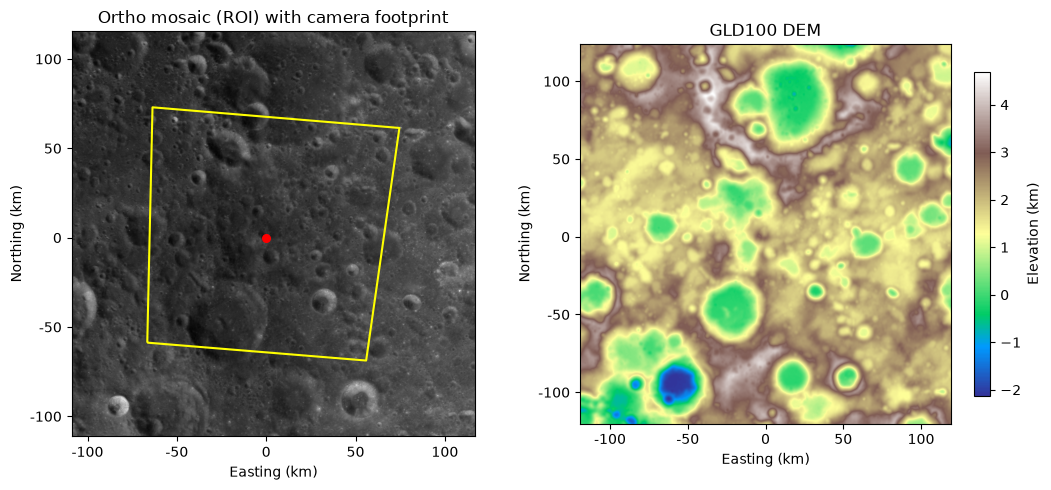

In [5]:
_ = plotting.plot_dem_ortho(dem_ortho_result, camera)

## Phase 4: render with `sat_sim` + the real camera pose

`dataset.populate()` already generated `hillshade` above. `render.run_sat_sim` calls
`sat_sim --camera-list` against the Phase 3 DEM/ortho to produce it, then ASP's `cam_gen` to
convert that same camera to a CSM Frame model-state JSON (the "ISD" sidecar).

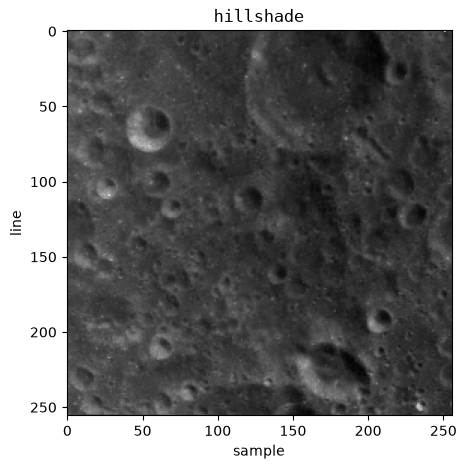

In [6]:
_ = plotting.plot_synthetic_render(entry.hillshade.raster_path, label=r"$\mathtt{hillshade}$")

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string"
convention; skip it before parsing.

In [7]:
model_name, csm_state = trntest.read_csm_state(entry.hillshade.sidecar_json_path)

print("Model name:", model_name)
for key in ["m_focalLength", "m_nLines", "m_nSamples", "m_ccdCenter", "m_currentParameterValue"]:
    print(f"{key}: {csm_state[key]}")

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 249.58449650154427
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [132.9415639468783, 128.0]
m_currentParameterValue: [-1436043.1493196595, 265174.67205529904, 1154372.7413038197, 0.6963701736361889, 0.5308925471925776, 0.32152147339855486, 0.3603409867735047]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame)
and the last 4 are the orientation quaternion -- matching the `C`/`R` computed from SPICE in Phase 2.

### North-up rotation (display only)

The sensor's pixel axes are a fixed hardware convention, but which way is "north" in that fixed
convention depends on the pass (ascending vs. descending, plus yaw state). `trntest.orientation`
picks, per image, the multiple of 90 degrees whose on-screen "up" is closest to true north, applied
only to the plotted arrays below -- the camera model itself is untouched.

In [8]:
rotations = entry.rotations
print(
    f"hillshade: rotate {rotations.k_synthetic * 90} deg for north-up (residual {rotations.dev_synthetic_deg:.1f} deg from true north)"
)
print(
    f"crop: rotate {rotations.k_crop * 90} deg for north-up (residual {rotations.dev_crop_deg:.1f} deg from true north)"
)

hillshade: rotate 180 deg for north-up (residual 8.1 deg from true north)
crop: rotate 0 deg for north-up (residual 4.5 deg from true north)


### Tie points (display only)

`session.select_tie_points()` picks 5 points (4 corners + center) in the ground area both
`hillshade` and `crop` cover, and projects them into `hillshade`'s exact pixel coordinates. Reused
below to mark the same ground points on each candidate's panel, and for the direct comparison
in Phase 7.

In [9]:
tie_point_results = session.select_tie_points(camera, frame_timing)
for name, r in tie_point_results.items():
    print(f"{name:12s} lonlat={r['lonlat']}  synthetic_px={r['synthetic_px']}")

top_left     lonlat=(167.5517234667783, 40.432739806469776)  synthetic_px=(np.float64(224.16703050296638), np.float64(221.4432844045221))
top_right    lonlat=(171.84068986765806, 40.428408854388834)  synthetic_px=(np.float64(37.802532853638624), np.float64(236.05209457501667))
center       lonlat=(169.57486295387, 38.762076131301)  synthetic_px=(np.float64(128.0), np.float64(132.9415639468783))
bottom_left  lonlat=(167.64272541414726, 37.15508817733422)  synthetic_px=(np.float64(216.30569596992072), np.float64(25.63445121710258))
bottom_right lonlat=(171.73878264384567, 37.15095213872898)  synthetic_px=(np.float64(12.531283223718646), np.float64(43.078304365408286))


## Phase 5: does `hillshade`'s geometry check out?

The real question for each TRN test image candidate is whether its geometry matches reality, not
just whether it looks plausible. Both this phase and Phase 6 check that two ways against the same
reference -- the basemap from Phase 3:

- **A: raw image quality.** `hillshade`'s pixels, rotated north-up and scaled to real km, next
  to a plain crop of the basemap covering the same footprint, both marked with the same tie points.
- **B: pixel-for-pixel alignment.** `hillshade` reprojected onto the map through its camera model
  (`mapproject`) and overlaid directly on the basemap, as an auto-blinking GIF that alternates the
  overlay against the basemap.

(Phase 7 puts 5A's and 6A's panels side by side, for an easier look at `hillshade` and `crop`
themselves.)

5B and 6B also draw the Robbins et al. (2019) lunar crater database as an extra layer on the
overlay: if the ellipses land on the actual crater rims visible in the basemap, that's independent
confirmation the overlay's geo-registration is correct.

In [10]:
crater_layer = craters.crater_overlay_layer(
    dem_ortho_result.ortho,
    entry.per_image_config,
    min_major_km=9.0,
    min_arc_img=0.75,
    color="#ffddbb",
    linewidth=2.0,
    linestyle=(0, (1, 6)),
)
crater_layers = [crater_layer] if crater_layer is not None else None
print(f"Robbins craters in view: {len(crater_layer.geoseries) if crater_layer is not None else 0}")

Robbins craters in view: 51


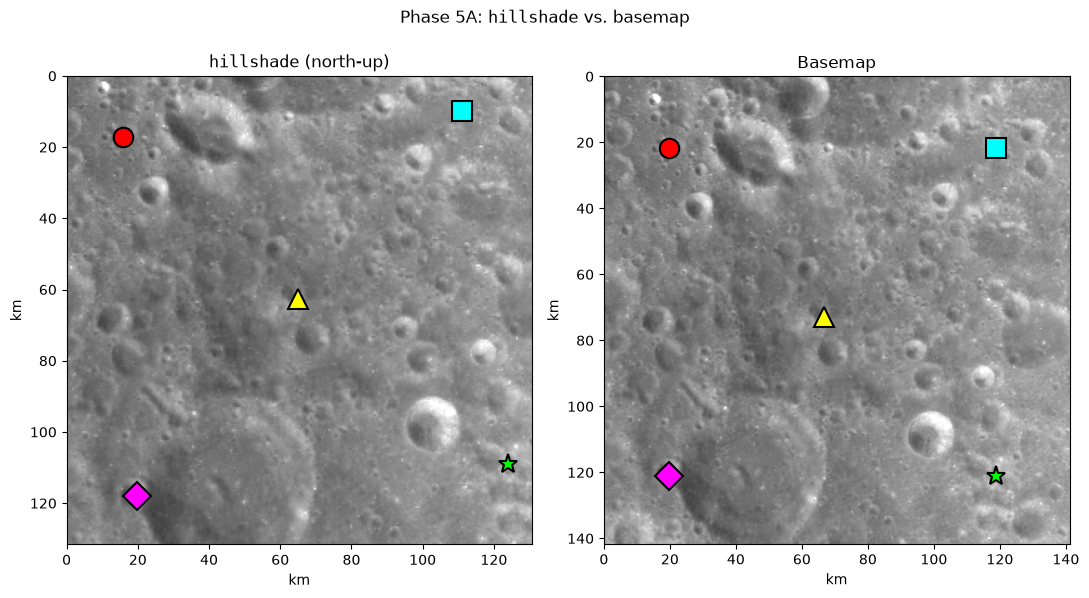

In [11]:
_ = entry.hillshade.plot_vs_basemap(
    tie_point_results=tie_point_results,
    title=r"Phase 5A: $\mathtt{hillshade}$ vs. basemap",
    render_label=r"$\mathtt{hillshade}$",
)


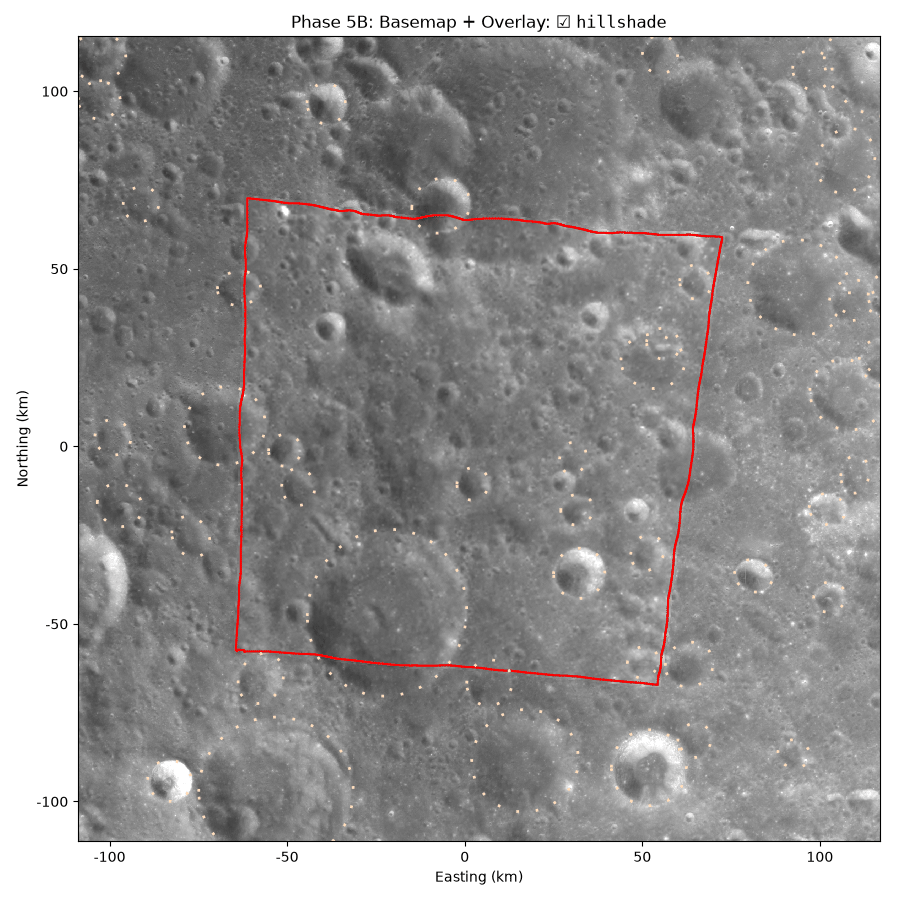

In [12]:
entry.hillshade.plot_overlay(
    title="Phase 5B: Basemap + Overlay",
    overlay_label=r"$\mathtt{hillshade}$",
    layers=crater_layers,
)

## Phase 6: does `crop`'s geometry check out?

The same two-style check as Phase 5, for `crop` (see the table above for its processing steps).

Unlike 5B, 6B doesn't go through ASP's `mapproject` via a CSM sidecar -- `usgscsm`'s ground-to-image
solve is unreliable for this sensor's Pushframe camera model (see `isis_wac.py`'s module
docstring). `TrnTestCropImage.plot_overlay()` instead uses ISIS's native camera model via
`cam2map`.

In [13]:
tie_point_results = tie_points.resolve_crop_pixels(tie_point_results, entry.crop_result)
for name, r in tie_point_results.items():
    print(f"{name:12s} crop_px={r['crop_px']}")

top_left     crop_px=(np.float64(100.0398766253839), np.float64(187.3197188728517))
top_right    crop_px=(np.float64(592.370839024044), np.float64(132.33136778210428))
center       crop_px=(np.float64(351.48236603197523), np.float64(494.041376524978))
bottom_left  crop_px=(np.float64(134.0100307742964), np.float64(842.758526149667))
bottom_right crop_px=(np.float64(627.1115274754687), np.float64(790.5649773424482))


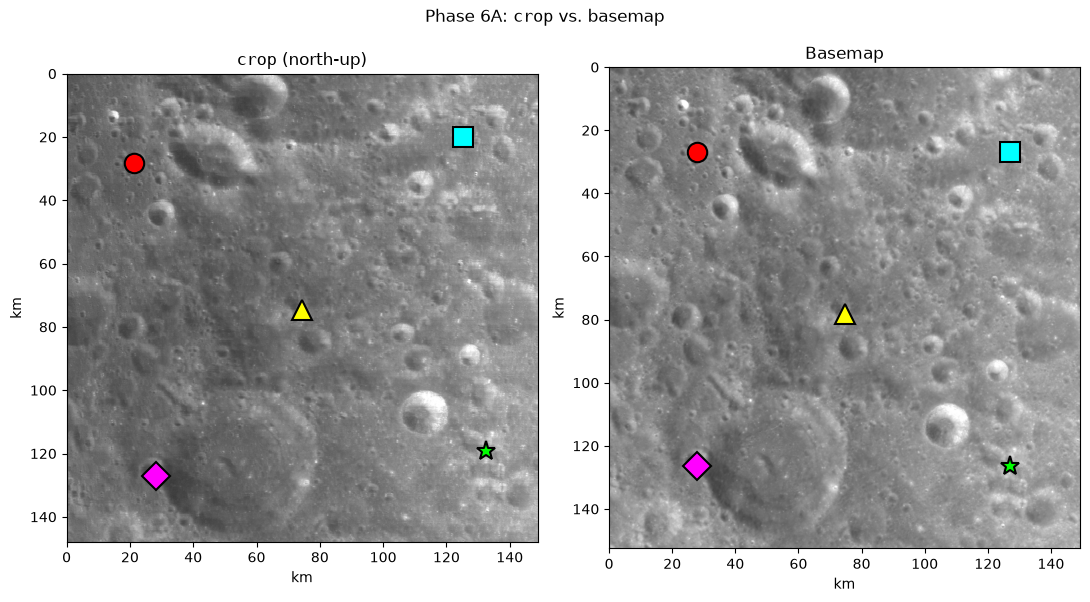

In [14]:
_ = entry.crop.plot_vs_basemap(
    tie_point_results=tie_point_results,
    title=r"Phase 6A: $\mathtt{crop}$ vs. basemap",
    render_label=r"$\mathtt{crop}$",
)


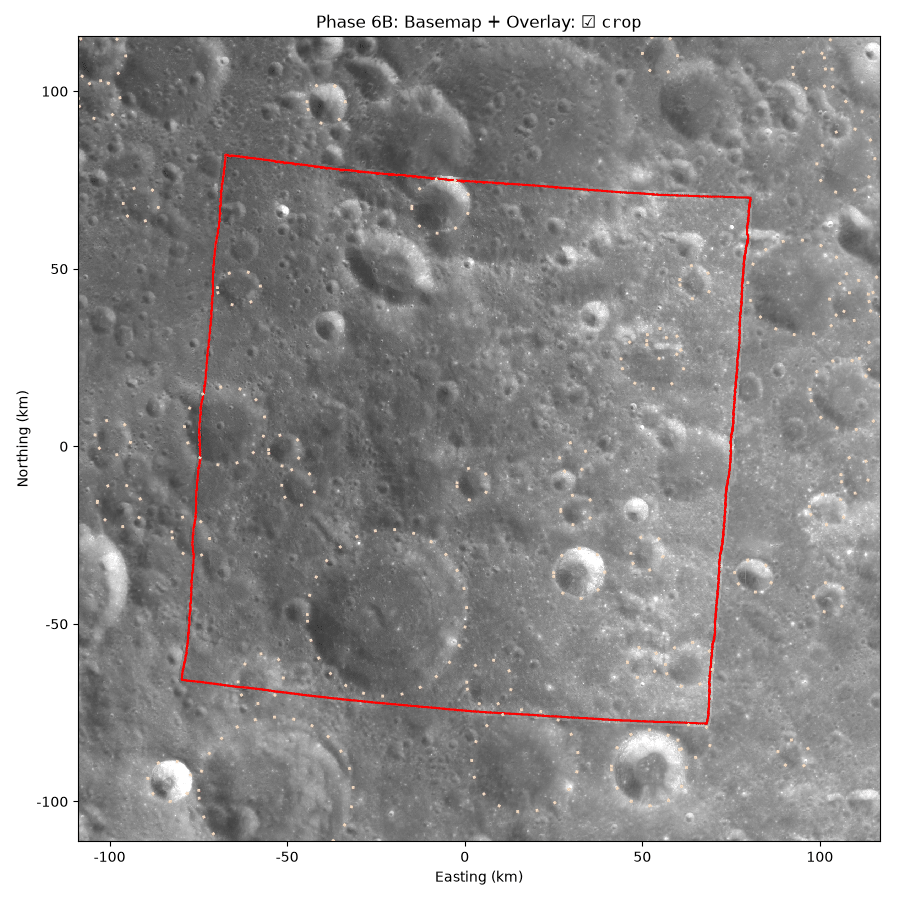

In [15]:
entry.crop.plot_overlay(
    title="Phase 6B: Basemap + Overlay",
    overlay_label=r"$\mathtt{crop}$",
    layers=crater_layers,
)

## Phase 7: `hillshade` vs. `crop`, side by side

5A's and 6A's panels, put together directly. `plotting.plot_isis_comparison()` additionally
brightness-matches the two panels (`crop`'s calibrated I/F and `hillshade`'s texture-brightness
values are on different numeric scales) and interpolates across `crop`'s small dead-pixel gaps for
display.

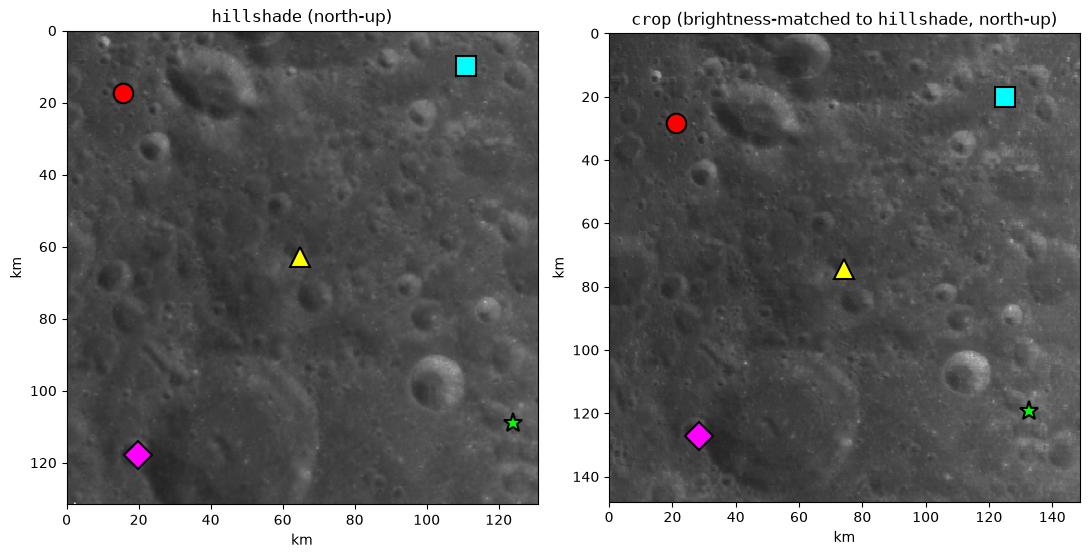

In [16]:
_ = plotting.plot_isis_comparison(
    camera,
    tie_point_results,
    entry.hillshade.raster_path,
    entry.crop.raster_path,
    rotations,
    synthetic_label=r"$\mathtt{hillshade}$",
    real_label=r"$\mathtt{crop}$",
)

## Phase 8: does `reproject` check out?

`reproject` shares its `Camera` with `hillshade` (same pose, same corrected FOV) -- see the table
above for what it's textured from instead.

Because its geometry is byte-identical to `hillshade`'s, already validated in Phase 5, there's no
need to re-run the basemap checks a third time. What's specific to `reproject` instead: does
`crop`'s footprint actually cover the synthetic camera's FOV out to its corners (checked below as
a valid-pixel fraction), and does texturing from `crop` -- already at (nearly) this render's real
acquisition geometry, so no relighting step needed, unlike `hillshade` -- produce something that
looks like `hillshade`.

In [17]:
reproject_data = plotting.read_raster_band(entry.reproject.raster_path)
valid_frac = plotting.valid_pixel_mask(reproject_data).mean()
print(f"reproject valid pixels: {valid_frac:.1%}")

reproject valid pixels: 100.0%


### Comparing `hillshade` and `reproject` directly

Both are `sat_sim` renders through the exact same `Camera`, so unlike every other comparison in
this notebook, this one needs no reprojection step: `plotting.plot_render_toggle` reads each
render's raw pixels directly, brightness-matches them, and blinks between them. If texture source
were the only thing that mattered, the two should blink as the same scene lit slightly
differently -- expected, since `hillshade` is relit for this geometry from a fixed-geometry
reflectance source and `reproject` isn't relit at all (see the table above).


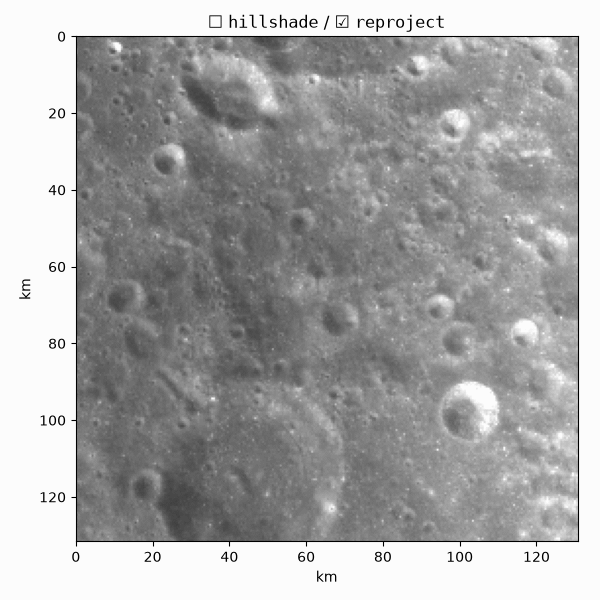

In [18]:
plotting.plot_render_toggle(
    entry.hillshade.raster_path,
    entry.reproject.raster_path,
    entry.rotations.k_synthetic,
    entry.hillshade.width_km,
    entry.hillshade.height_km,
    r"$\mathtt{hillshade}$",
    r"$\mathtt{reproject}$",
)